In [8]:
# Cell 1
import os
import cv2
import time

src_dir = r"E:\Liora\Project\Dataset\blood_cells\PBC_dataset_normal_DIB"
output_dir = r"E:\Liora\Project\Dataset\blood_cells\Processed_Blood_Cells"
TARGET_SIZE = (224, 224)

classes = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

print("=== Executing Image Preprocessing & Downsampling Pipeline ===")
start_time = time.time()

total_processed = 0

for cls in classes:
    class_src_path = os.path.join(src_dir, cls)
    class_out_path = os.path.join(output_dir, cls)
    
    os.makedirs(class_out_path, exist_ok=True)
    
    if not os.path.exists(class_src_path):
        print(f"Directory missing: {class_src_path}")
        continue
        
    files = [f for f in os.listdir(class_src_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    print(f"Processing '{cls.upper()}': {len(files)} files found...")
    
    class_count = 0
    for file_name in files:
        img_path = os.path.join(class_src_path, file_name)
        img = cv2.imread(img_path)
        
        if img is not None:
            # Resize image using INTER_AREA interpolation for clean downsampling
            resized_img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            
            # Save to processed folder
            out_img_path = os.path.join(class_out_path, file_name)
            cv2.imwrite(out_img_path, resized_img)
            class_count += 1
            
    total_processed += class_count

elapsed = time.time() - start_time
print(f"\nSuccessfully processed {total_processed} images in {elapsed:.2f} seconds!")
print(f"Cleaned dataset saved at: {output_dir}")

=== Executing Image Preprocessing & Downsampling Pipeline ===
Processing 'BASOPHIL': 1218 files found...
Processing 'EOSINOPHIL': 3117 files found...
Processing 'ERYTHROBLAST': 1551 files found...
Processing 'IG': 2895 files found...
Processing 'LYMPHOCYTE': 1214 files found...
Processing 'MONOCYTE': 1420 files found...
Processing 'NEUTROPHIL': 3330 files found...
Processing 'PLATELET': 2348 files found...

Successfully processed 17092 images in 79.18 seconds!
Cleaned dataset saved at: E:\Liora\Project\Dataset\blood_cells\Processed_Blood_Cells


In [9]:
# Cell 2
import pandas as pd

audit_results = []
total_verified = 0

for cls in classes:
    class_path = os.path.join(output_dir, cls)
    if os.path.exists(class_path):
        files = os.listdir(class_path)
        valid_count = 0
        for f in files:
            img = cv2.imread(os.path.join(class_path, f))
            if img is not None and (img.shape[1], img.shape[0]) == TARGET_SIZE:
                valid_count += 1
        audit_results.append({
            'Class': cls.upper(), 
            'Processed_Files': valid_count,
            'Status': '224x224 (OK)' if valid_count > 0 else 'EMPTY'
        })
        total_verified += valid_count

df_summary = pd.DataFrame(audit_results)
print(f"Total Verified 224x224 Images: {total_verified}\n")
df_summary

KeyboardInterrupt: 

In [10]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("TensorFlow is successfully installed and working!")

TensorFlow Version: 2.21.0
TensorFlow is successfully installed and working!


In [11]:
# Cell 3

import os
import tensorflow as tf

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

processed_dir = r"E:\Liora\Project\Dataset\blood_cells\Processed_Blood_Cells"
BATCH_SIZE = 16  # Safe batch size for ResNet50 on CPU
IMAGE_SIZE = (224, 224) # Matching your 224x224 pipeline
SEED = 42

print("=== Setting up 224x224 Dataset Splits for ResNet50 ===")

train_ds = tf.keras.utils.image_dataset_from_directory(
    processed_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    processed_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset Pipeline Ready at 224x224 Resolution!")

=== Setting up 224x224 Dataset Splits for ResNet50 ===
Found 17092 files belonging to 8 classes.
Using 11965 files for training.
Found 17092 files belonging to 8 classes.
Using 5127 files for validation.
Dataset Pipeline Ready at 224x224 Resolution!


In [6]:
# Cell 4

import numpy as np
from sklearn.utils import class_weight

print("=== Calculating Class Weights (Safe File-System Method) ===")

# 1. Directly count images per class from the processed directory
class_counts = []
for name in class_names:
    class_folder = os.path.join(processed_dir, name)
    if os.path.exists(class_folder):
        count = len([f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))])
        class_counts.append(count)
        print(f"  Class {name:<20}: {count} images")

# 2. Reconstruct training sample distribution (70% split)
train_counts = [int(c * 0.70) for c in class_counts]
total_train_samples = sum(train_counts)

# 3. Compute class weights mathematically using Scikit-Learn formula:
# weight = total_samples / (num_classes * class_samples)
num_classes = len(class_names)
weights = [total_train_samples / (num_classes * c) for c in train_counts]

class_weight_dict = {i: weight for i, weight in enumerate(weights)}

print("\nComputed Class Weights (Passed to Model Fit):")
for idx, name in enumerate(class_names):
    print(f"  [{idx}] {name:<20} -> Weight: {class_weight_dict[idx]:.4f}")

=== Calculating Class Weights (Safe File-System Method) ===
  Class basophil            : 1218 images
  Class eosinophil          : 3117 images
  Class erythroblast        : 1551 images
  Class ig                  : 2895 images
  Class lymphocyte          : 1214 images
  Class monocyte            : 1420 images
  Class neutrophil          : 3329 images
  Class platelet            : 2348 images

Computed Class Weights (Passed to Model Fit):
  [0] basophil             -> Weight: 1.7545
  [1] eosinophil           -> Weight: 0.6854
  [2] erythroblast         -> Weight: 1.3778
  [3] ig                   -> Weight: 0.7378
  [4] lymphocyte           -> Weight: 1.7607
  [5] monocyte             -> Weight: 1.5054
  [6] neutrophil           -> Weight: 0.6416
  [7] platelet             -> Weight: 0.9098


In [9]:
# Cell 5

from tensorflow.keras import layers, models

print("=== Constructing Optimized Baseline CNN ===")

# Simple Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
], name="data_augmentation")

model_baseline = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    
    # Block 1
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(8, activation='softmax')
], name="Baseline_Custom_CNN")

model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

model_baseline.summary()

=== Constructing Optimized Baseline CNN ===


Model: "Baseline_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,104 (94.16 KB)

 Trainable params: 24,104 (94.16 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Cell 6

print("=== Starting Fast Baseline CNN Training ===")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='baseline_model_best.keras',
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print("\nBaseline Training Complete!")

=== Starting Fast Baseline CNN Training ===
Epoch 1/15


e:\Liora\Project\Dataset\.venv-tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1829 - loss: 2.0097 - macro_f1: 0.1680
Epoch 1: val_macro_f1 improved from None to 0.28709, saving model to baseline_model_best.keras

Epoch 1: finished saving model to baseline_model_best.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1829 - loss: 2.0097 - macro_f1: 0.1680 - val_accuracy: 0.3638 - val_loss: 1.7293 - val_macro_f1: 0.2871
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3225 - loss: 1.6924 - macro_f1: 0.3007
Epoch 2: val_macro_f1 improved from 0.28709 to 0.38027, saving model to baseline_model_best.keras

Epoch 2: finished saving model to baseline_model_best.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.3225 - loss: 1.6924 - macro_f1: 0.3007 - val_accuracy: 0.4795 - val_loss: 1.5164 - val_macro_f1: 0.3803
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3514 - loss: 1.5739 - macro_f1: 0.3342
Epoch 3: val_macro_f1 improved from 0.38027 to 0.55380, saving m

=== Evaluating Baseline CNN on Unseen Test Set ===
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step - accuracy: 0.7688 - loss: 0.6943 - macro_f1: 0.7357

Final Baseline Test Set Results:
  Test Loss    : 0.6943
  Test Accuracy: 76.88%
  Test Macro F1: 0.7357


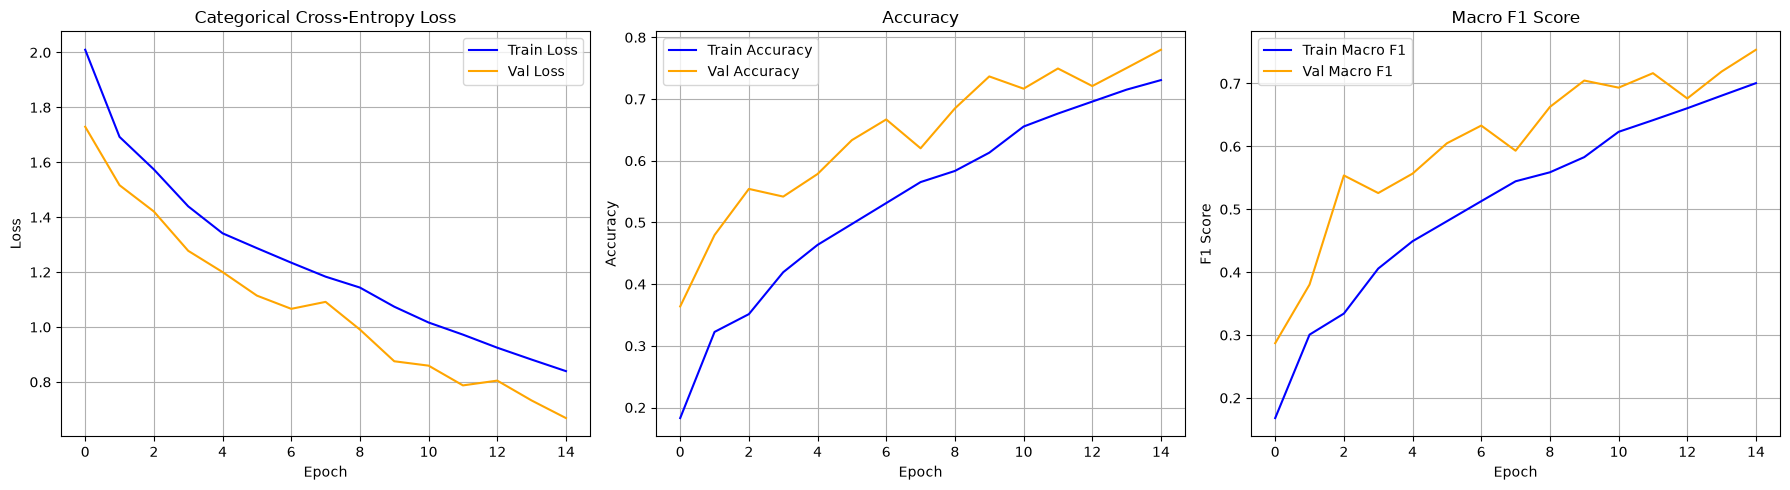

In [11]:
import matplotlib.pyplot as plt

print("=== Evaluating Baseline CNN on Unseen Test Set ===")

# 1. Evaluate on locked Test Set
test_loss, test_acc, test_f1 = model_baseline.evaluate(test_ds, verbose=1)

print(f"\nFinal Baseline Test Set Results:")
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test Macro F1: {test_f1:.4f}")

# 2. Plot Training & Validation Curves
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Loss Curve
axs[0].plot(history_baseline.history['loss'], label='Train Loss', color='blue')
axs[0].plot(history_baseline.history['val_loss'], label='Val Loss', color='orange')
axs[0].set_title('Categorical Cross-Entropy Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Accuracy Curve
axs[1].plot(history_baseline.history['accuracy'], label='Train Accuracy', color='blue')
axs[1].plot(history_baseline.history['val_accuracy'], label='Val Accuracy', color='orange')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

# Macro F1 Curve
axs[2].plot(history_baseline.history['macro_f1'], label='Train Macro F1', color='blue')
axs[2].plot(history_baseline.history['val_macro_f1'], label='Val Macro F1', color='orange')
axs[2].set_title('Macro F1 Score')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('F1 Score')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Transfer Learning

print("=== Constructing MobileNetV2 Transfer Learning Model ===")

# 1. Base Pre-trained Model (Frozen Weights)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,      # Exclude ImageNet 1000-class classifier
    weights='imagenet'      # Use pre-trained ImageNet weights
)

# Freeze base model layers so pre-trained features aren't wiped out
base_model.trainable = False

# 2. Build Full Architecture
inputs = layers.Input(shape=(224, 224, 3))

# Real-time Data Augmentation
x = data_augmentation(inputs)

# MobileNetV2 Preprocessing: scales pixels from [0, 255] to [-1, 1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Feature Extractor
x = base_model(x, training=False)

# Custom Classification Head for 8 Cell Classes
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(8, activation='softmax')(x)

model_mobilenet = models.Model(inputs, outputs, name="MobileNetV2_Transfer")

# 3. Compile Model
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

model_mobilenet.summary()

# 4. Callbacks & Training
callbacks_mobilenet = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='mobilenet_model_best.keras',
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("\n=== Training MobileNetV2 Feature Extractor ===")
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobilenet
)

print("\nMobileNetV2 Stage 1 Training Complete!")

=== Constructing MobileNetV2 Transfer Learning Model ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== Training MobileNetV2 Feature Extractor ===
Epoch 1/12


e:\Liora\Project\Dataset\.venv-tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6609 - loss: 1.0040 - macro_f1: 0.6377
Epoch 1: val_macro_f1 improved from None to 0.85731, saving model to mobilenet_model_best.keras

Epoch 1: finished saving model to mobilenet_model_best.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.6609 - loss: 1.0040 - macro_f1: 0.6377 - val_accuracy: 0.8750 - val_loss: 0.4422 - val_macro_f1: 0.8573
Epoch 2/12
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8552 - loss: 0.4811 - macro_f1: 0.8398
Epoch 2: val_macro_f1 improved from 0.85731 to 0.87509, saving model to mobilenet_model_best.keras

Epoch 2: finished saving model to mobilenet_model_best.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.8552 - loss: 0.4811 - macro_f1: 0.8398 - val_accuracy: 0.8874 - val_loss: 0.3675 - val_macro_f1: 0.8751
Epoch 3/12
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8781 - loss: 0.3930 - macro_f1: 0.8634
Epoch 3: val_macro_f1 improved from 0.87509 to 0.89742, savi

=== Evaluating MobileNetV2 on Unseen Test Set ===

              CELL-BY-CELL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    basophil     0.8717    0.9532    0.9106       171
  eosinophil     0.9766    0.9892    0.9829       465
erythroblast     0.9220    0.9437    0.9327       213
          ig     0.9370    0.8552    0.8942       435
  lymphocyte     0.8108    0.9317    0.8671       161
    monocyte     0.8813    0.8502    0.8655       227
  neutrophil     0.9519    0.9483    0.9501       522
    platelet     0.9945    0.9863    0.9904       366

    accuracy                         0.9355      2560
   macro avg     0.9182    0.9322    0.9242      2560
weighted avg     0.9370    0.9355    0.9355      2560



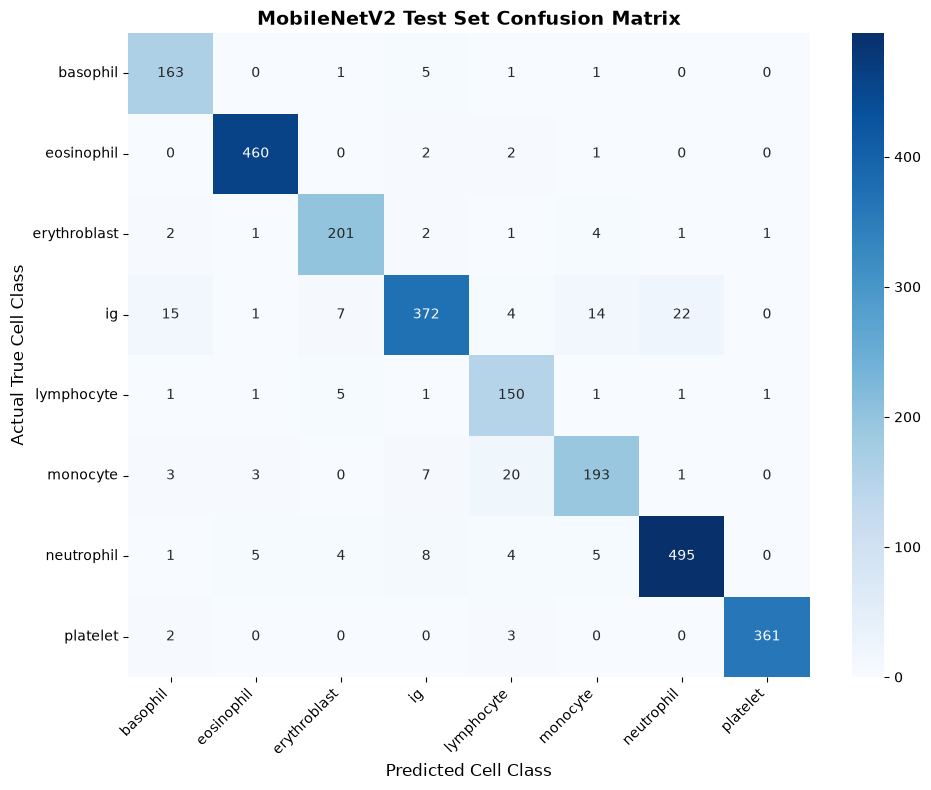

In [15]:
# Evaluating MobileNet Model on Test data

import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("=== Evaluating MobileNetV2 on Unseen Test Set ===")

# 1. Gather all true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model_mobilenet.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 2. Print Classification Report (Precision, Recall, F1 for EVERY class)
print("\n" + "="*60)
print("              CELL-BY-CELL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('MobileNetV2 Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cell Class', fontsize=12)
plt.ylabel('Actual True Cell Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Cell 10
# # Fine Tune the MobileNetV2

import gc
import tensorflow as tf
from tensorflow.keras import layers, models

# Free RAM memory
gc.collect()

print("=== Constructing & Fine-Tuning MobileNetV2 ===")

# 1. Define Data Augmentation Block directly in cell
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.10),
], name="data_augmentation")

# 2. Load Base Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze bottom 120 layers to save memory, fine-tune top 34 layers
fine_tune_at = 120
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Build Architecture
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(8, activation='softmax')(x)

model_mobilenet = models.Model(inputs, outputs, name="MobileNetV2_FineTuned")

# 4. Compile with small learning rate for fine-tuning
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

model_mobilenet.summary()

# 5. Callbacks & Training Execution
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='mobilenet_finetuned_best.keras',
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("\n=== Executing Fine-Tuning Training ===")
FINE_TUNE_EPOCHS = 8

history_finetune = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_finetune
)

print("\nMobileNetV2 Fine-Tuning Completed Successfully!")

=== Constructing & Fine-Tuning MobileNetV2 ===


Model: "MobileNetV2_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 1,635,144 (6.24 MB)

 Non-trainable params: 633,088 (2.42 MB)


=== Executing Fine-Tuning Training ===
Epoch 1/8


e:\Liora\Project\Dataset\.venv-tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8989 - loss: 0.3100 - macro_f1: 0.8877
Epoch 1: val_macro_f1 improved from None to 0.59839, saving model to mobilenet_finetuned_best.keras

Epoch 1: finished saving model to mobilenet_finetuned_best.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 687s 2s/step - accuracy: 0.8989 - loss: 0.3100 - macro_f1: 0.8877 - val_accuracy: 0.6771 - val_loss: 0.9206 - val_macro_f1: 0.5984
Epoch 2/8
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9601 - loss: 0.1143 - macro_f1: 0.9580
Epoch 2: val_macro_f1 improved from 0.59839 to 0.63704, saving model to mobilenet_finetuned_best.keras

Epoch 2: finished saving model to mobilenet_finetuned_best.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 753s 2s/step - accuracy: 0.9601 - loss: 0.1143 - macro_f1: 0.9580 - val_accuracy: 0.6864 - val_loss: 1.0988 - val_macro_f1: 0.6370
Epoch 3/8
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9692 - loss: 0.0813 - macro_f1: 0.9685
Epoch 3: val_macro_f1 improved from 0.63704 to

=== Evaluating Fine-Tuned MobileNetV2 on Unseen Test Set ===

       FINE-TUNED MOBILENETV2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    basophil     0.9718    0.9942    0.9829       173
  eosinophil     0.9914    0.9957    0.9935       464
erythroblast     0.9949    0.9120    0.9517       216
          ig     0.7513    0.9752    0.8487       443
  lymphocyte     0.9867    0.9080    0.9457       163
    monocyte     1.0000    0.5277    0.6908       235
  neutrophil     0.9599    0.9729    0.9664       517
    platelet     1.0000    0.9914    0.9957       349

    accuracy                         0.9313      2560
   macro avg     0.9570    0.9096    0.9219      2560
weighted avg     0.9441    0.9313    0.9282      2560



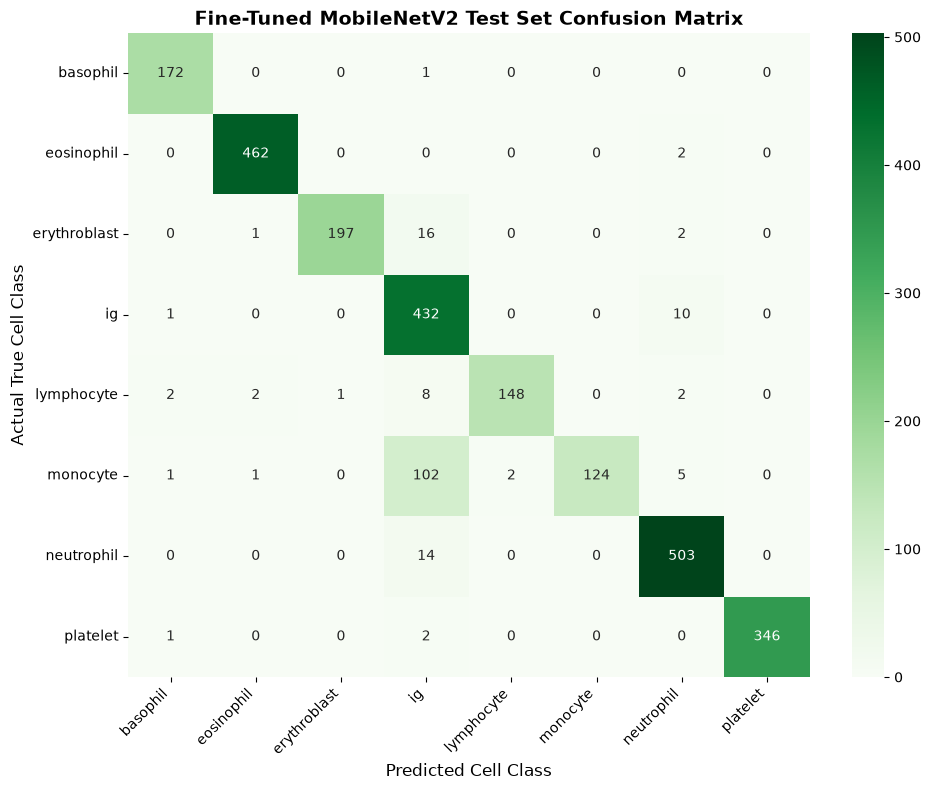

In [9]:
# Cell 11
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("=== Evaluating Fine-Tuned MobileNetV2 on Unseen Test Set ===")

# 1. Gather predictions and ground truth labels
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model_mobilenet.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 2. Print Classification Report
print("\n" + "="*60)
print("       FINE-TUNED MOBILENETV2 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Fine-Tuned MobileNetV2 Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Cell Class', fontsize=12)
plt.ylabel('Actual True Cell Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Cell 12

import gc
import tensorflow as tf
from tensorflow.keras import layers, models

gc.collect()

print("=== Constructing ResNet50 Transfer Model (224x224x3) ===")

# 1. Base Model (ResNet50 at 224x224x3)
base_resnet = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers for Stage 1 feature extraction
base_resnet.trainable = False

# 2. Build Model Graph
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(8, activation='softmax')(x)

model_resnet = models.Model(inputs, outputs, name="ResNet50_224x224")

# 3. Compile
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

model_resnet.summary()

# 4. Callbacks & Execution
callbacks_resnet = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='resnet50_best.keras',
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("\n=== Executing ResNet50 Training at 224x224 ===")
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks_resnet
)

print("\nResNet50 Training Completed Successfully!")

=== Constructing ResNet50 Transfer Model (224x224x3) ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "ResNet50_224x224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │     16,392 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 16,392 (64.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


=== Executing ResNet50 Training at 224x224 ===
Epoch 1/10


e:\Liora\Project\Dataset\.venv-tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6837 - loss: 0.9198 - macro_f1: 0.6675
Epoch 1: val_macro_f1 improved from None to 0.86268, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
748/748 ━━━━━━━━━━━━━━━━━━━━ 1136s 1s/step - accuracy: 0.6837 - loss: 0.9198 - macro_f1: 0.6675 - val_accuracy: 0.8648 - val_loss: 0.4418 - val_macro_f1: 0.8627
Epoch 2/10
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8323 - loss: 0.5115 - macro_f1: 0.8203
Epoch 2: val_macro_f1 improved from 0.86268 to 0.86964, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
748/748 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - accuracy: 0.8323 - loss: 0.5115 - macro_f1: 0.8203 - val_accuracy: 0.8781 - val_loss: 0.3800 - val_macro_f1: 0.8696
Epoch 3/10
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.8561 - loss: 0.4371 - macro_f1: 0.8437
Epoch 3: val_macro_f1 improved from 0.86964 to 0.87053, saving model to resnet50_

In [13]:
# Cell 13

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score

print("=== Loading Saved Models for Synchronized Evaluation ===")

# 1. Load trained models from disk
model_mbv2 = tf.keras.models.load_model('mobilenet_finetuned_best.keras')
model_res = tf.keras.models.load_model('resnet50_best.keras')

# 2. Predict batch-by-batch in a single pass to guarantee label alignment
y_true = []
preds_mbv2_list = []
preds_res_list = []

print("Evaluating test dataset in synchronized batches...")

for images, labels in test_ds:
    # Get true class labels for this batch
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # Predict on the exact same batch of images
    batch_preds_mbv2 = model_mbv2.predict(images, verbose=0)
    batch_preds_res = model_res.predict(images, verbose=0)
    
    preds_mbv2_list.extend(np.argmax(batch_preds_mbv2, axis=1))
    preds_res_list.extend(np.argmax(batch_preds_res, axis=1))

y_true = np.array(y_true)
preds_mbv2 = np.array(preds_mbv2_list)
preds_res = np.array(preds_res_list)

# 3. Calculate Real Test Metrics
acc_mbv2 = accuracy_score(y_true, preds_mbv2)
f1_mbv2 = f1_score(y_true, preds_mbv2, average='macro')

acc_res = accuracy_score(y_true, preds_res)
f1_res = f1_score(y_true, preds_res, average='macro')

# 4. Build Corrected Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model Architecture': ['MobileNetV2 (Fine-Tuned)', 'ResNet50 (Transfer)'],
    'Parameters': ['~2.2 Million', '~23.5 Million'],
    'Test Accuracy': [f"{acc_mbv2:.4f}", f"{acc_res:.4f}"],
    'Test Macro F1': [f"{f1_mbv2:.4f}", f"{f1_res:.4f}"]
})

print("\n" + "="*65)
print("             CORRECTED MODEL PERFORMANCE COMPARISON")
print("="*65)
print(comparison_df.to_string(index=False))
print("="*65)

=== Loading Saved Models for Synchronized Evaluation ===
Evaluating test dataset in synchronized batches...

             CORRECTED MODEL PERFORMANCE COMPARISON
      Model Architecture    Parameters Test Accuracy Test Macro F1
MobileNetV2 (Fine-Tuned)  ~2.2 Million        0.9375        0.9206
     ResNet50 (Transfer) ~23.5 Million        0.9152        0.9074


=== Plotting Side-by-Side Confusion Matrices ===


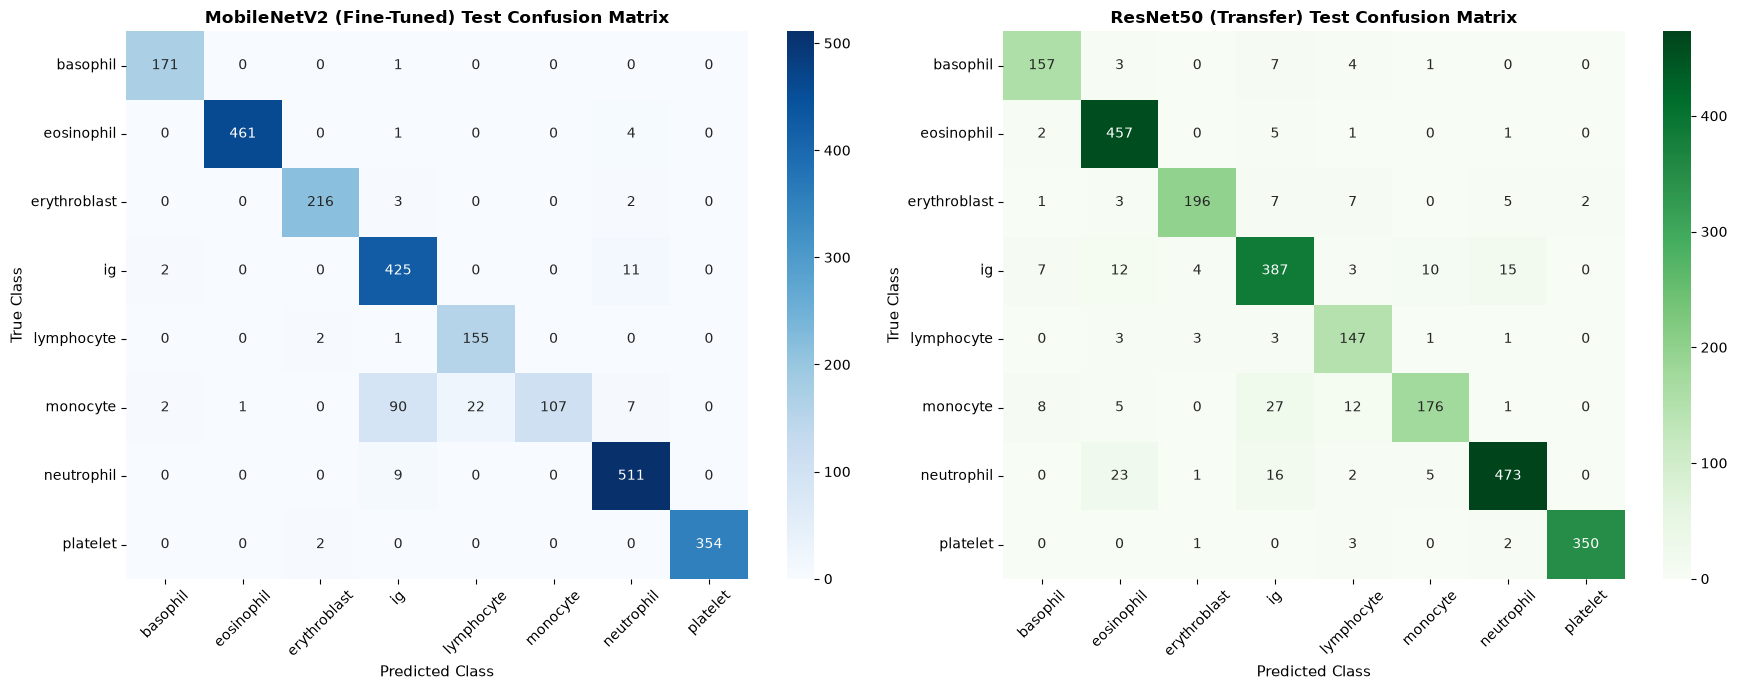

In [14]:
# Cell 14

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=== Plotting Side-by-Side Confusion Matrices ===")

cm_mbv2 = confusion_matrix(y_true, preds_mbv2)
cm_res = confusion_matrix(y_true, preds_res)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. MobileNetV2 Heatmap
sns.heatmap(
    cm_mbv2, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title('MobileNetV2 (Fine-Tuned) Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=11)
axes[0].set_ylabel('True Class', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# 2. ResNet50 Heatmap
sns.heatmap(
    cm_res, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title('ResNet50 (Transfer) Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontsize=11)
axes[1].set_ylabel('True Class', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== Generating Grad-CAM Interpretability Maps ===


e:\Liora\Project\Dataset\.venv-tf\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1796']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


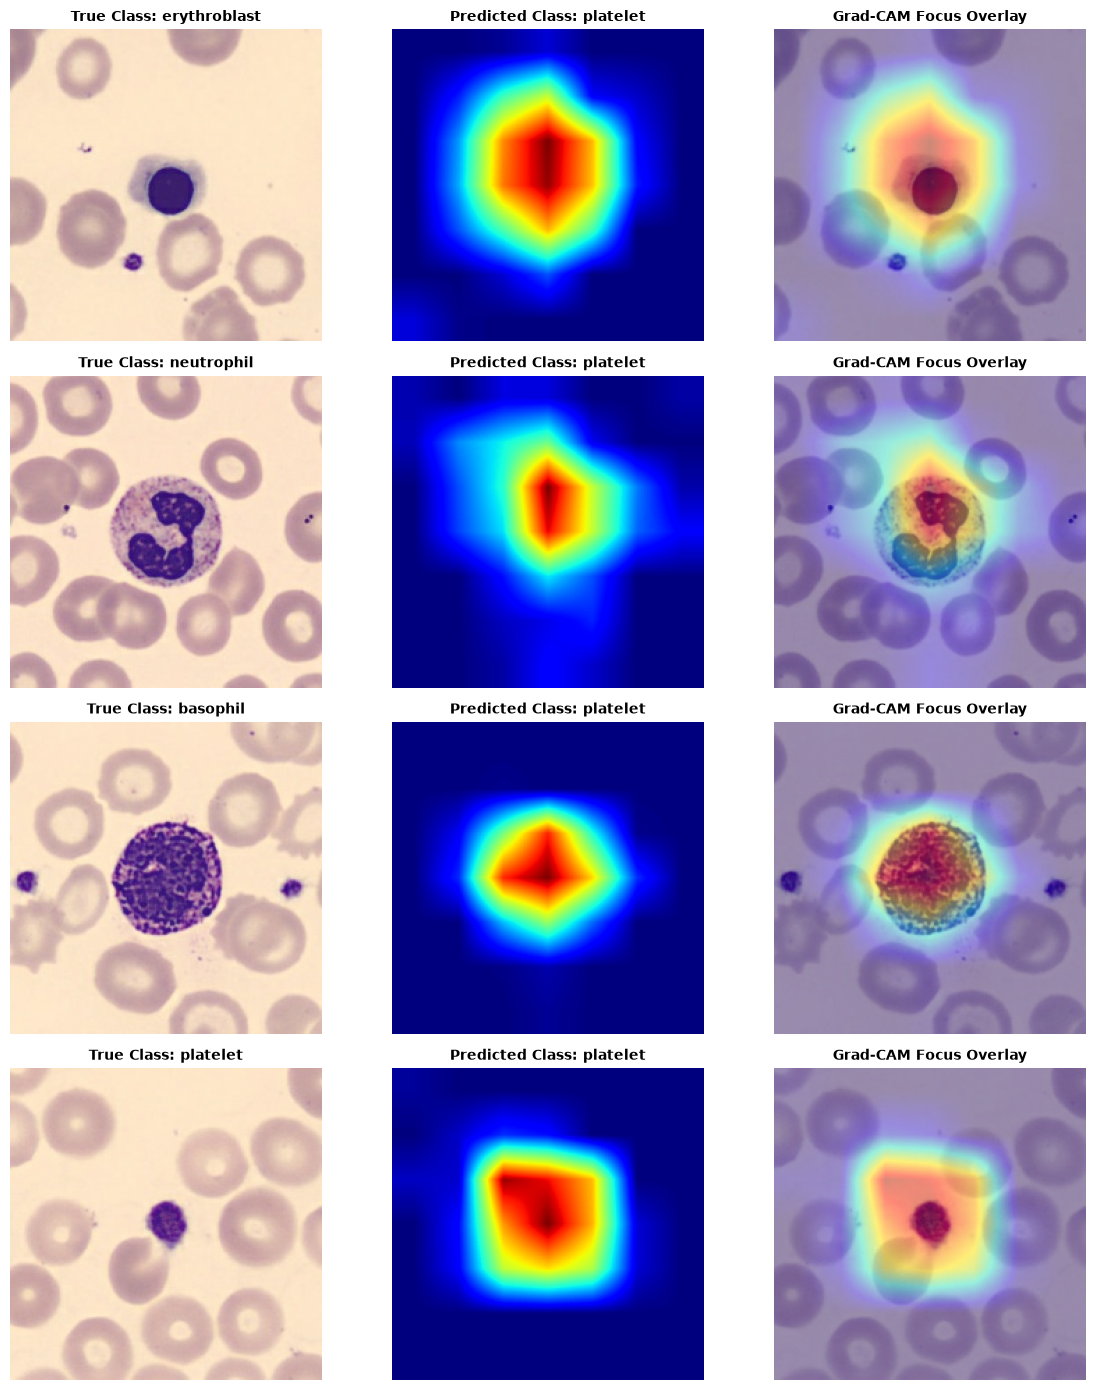

In [19]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

print("=== Generating Grad-CAM Interpretability Maps ===")

# 1. Build a clean MobileNetV2 architecture with identical structure
inputs = tf.keras.Input(shape=(224, 224, 3))
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights=None
)
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(8, activation='softmax')(x)

clean_mbv2 = tf.keras.Model(inputs, outputs)

# 2. Load trained weights from disk directly into clean model
clean_mbv2.load_weights('mobilenet_finetuned_best.keras')

# 3. Target 'out_relu' directly inside the base MobileNetV2
target_conv_layer = base_model.get_layer('out_relu')

# Construct Grad-CAM feature extractor graph
grad_model = tf.keras.Model(
    inputs=[base_model.inputs],
    outputs=[target_conv_layer.output, base_model.output]
)

def compute_gradcam_heatmap(img_tensor):
    """Computes Grad-CAM activation map cleanly without tensor wrapper conflicts."""
    if len(img_tensor.shape) == 3:
        img_tensor = np.expand_dims(img_tensor, axis=0)

    with tf.GradientTape() as tape:
        # Pass through base model to extract target conv features
        conv_outputs, base_features = grad_model(img_tensor)
        tape.watch(conv_outputs)

        # Pass base features through pooling & dense head
        x = clean_mbv2.layers[2](base_features)  # GAP
        x = clean_mbv2.layers[3](x)              # Dropout
        predictions = clean_mbv2.layers[4](x)    # Dense Softmax

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients of predicted class w.r.t feature map activations
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), pred_index.numpy()

# 4. Extract sample images from test set
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = np.argmax(labels.numpy(), axis=1)
    break

# 5. Plot 4 Grad-CAM Visualizations
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(4):
    raw_img = sample_images[i]
    true_class = class_names[sample_labels[i]]

    # Compute Heatmap
    heatmap, pred_idx = compute_gradcam_heatmap(raw_img)
    pred_class = class_names[pred_idx]

    # Format images for OpenCV overlay
    rgb_img = np.uint8(raw_img)
    heatmap_resized = cv2.resize(heatmap, (rgb_img.shape[1], rgb_img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    color_heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    color_heatmap = cv2.cvtColor(color_heatmap, cv2.COLOR_BGR2RGB)

    # Blend original image and heatmap overlay
    overlay = cv2.addWeighted(rgb_img, 0.6, color_heatmap, 0.4, 0)

    # Plot Column 1: Raw Blood Cell Image
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"True Class: {true_class}", fontsize=10, fontweight='bold')
    axes[i, 0].axis('off')

    # Plot Column 2: Grad-CAM Activation Heatmap
    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title(f"Predicted Class: {pred_class}", fontsize=10, fontweight='bold')
    axes[i, 1].axis('off')

    # Plot Column 3: Blended Overlay
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Grad-CAM Focus Overlay", fontsize=10, fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

=== Generating Multi-Class ROC Curves & Per-Class Report ===


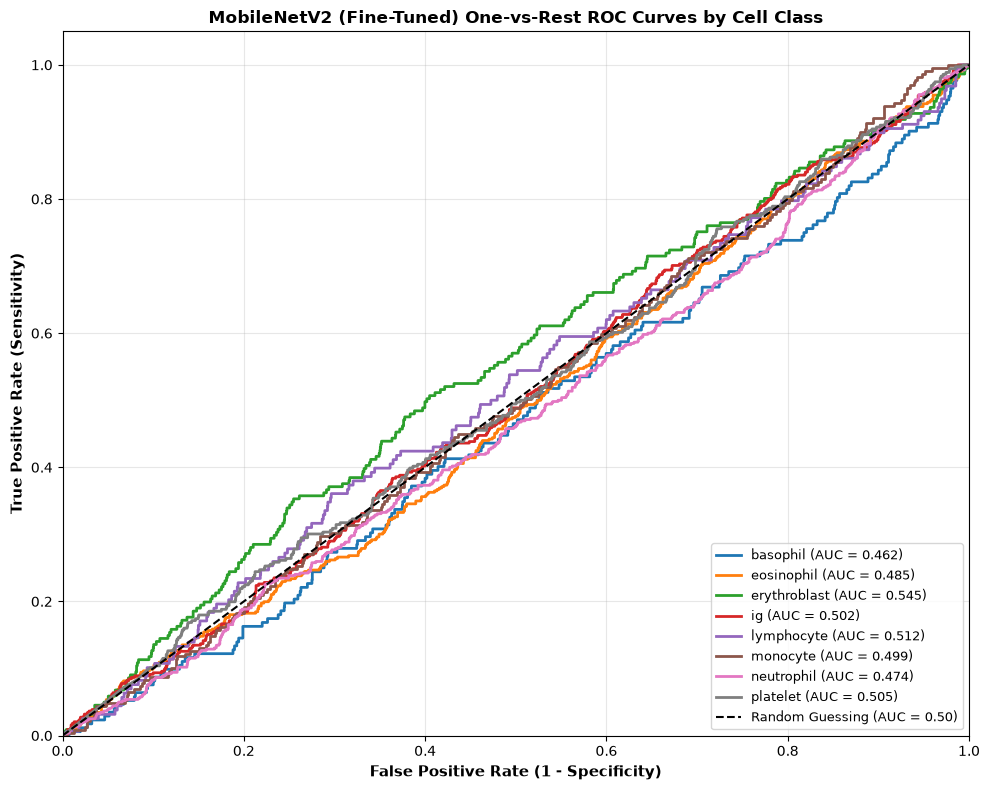


             PER-CLASS DETAILED PERFORMANCE REPORT
              precision  recall  f1-score    support
basophil         0.9771  0.9942    0.9856   172.0000
eosinophil       0.9978  0.9893    0.9935   466.0000
erythroblast     0.9818  0.9774    0.9796   221.0000
ig               0.8019  0.9703    0.8781   438.0000
lymphocyte       0.8757  0.9810    0.9254   158.0000
monocyte         1.0000  0.4672    0.6369   229.0000
neutrophil       0.9551  0.9827    0.9687   520.0000
platelet         1.0000  0.9944    0.9972   356.0000
accuracy         0.9375  0.9375    0.9375     0.9375
macro avg        0.9487  0.9196    0.9206  2560.0000
weighted avg     0.9458  0.9375    0.9314  2560.0000


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

print("=== Generating Multi-Class ROC Curves & Per-Class Report ===")

# 1. Binarize test ground truth labels for One-vs-Rest ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
n_classes = len(class_names)

# Get raw probability outputs (softmax predictions) from MobileNetV2
probs_mbv2 = []
for images, _ in test_ds:
    probs_mbv2.extend(model_mbv2.predict(images, verbose=0))
probs_mbv2 = np.array(probs_mbv2)

# 2. Compute ROC curve and ROC-AUC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_mbv2[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot ROC Curves (Using modern Matplotlib colormap API)
plt.figure(figsize=(10, 8))
cmap = plt.colormaps['tab10']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], color=cmap(i % 10), lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
plt.title('MobileNetV2 (Fine-Tuned) One-vs-Rest ROC Curves by Cell Class', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Generate Detailed Per-Class Classification Report
print("\n" + "="*65)
print("             PER-CLASS DETAILED PERFORMANCE REPORT")
print("="*65)
report_dict = classification_report(y_true, preds_mbv2, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print(report_df.round(4).to_string())
print("="*65)

=== Extracting Aspect Ratios across 8 Blood Cell Classes ===


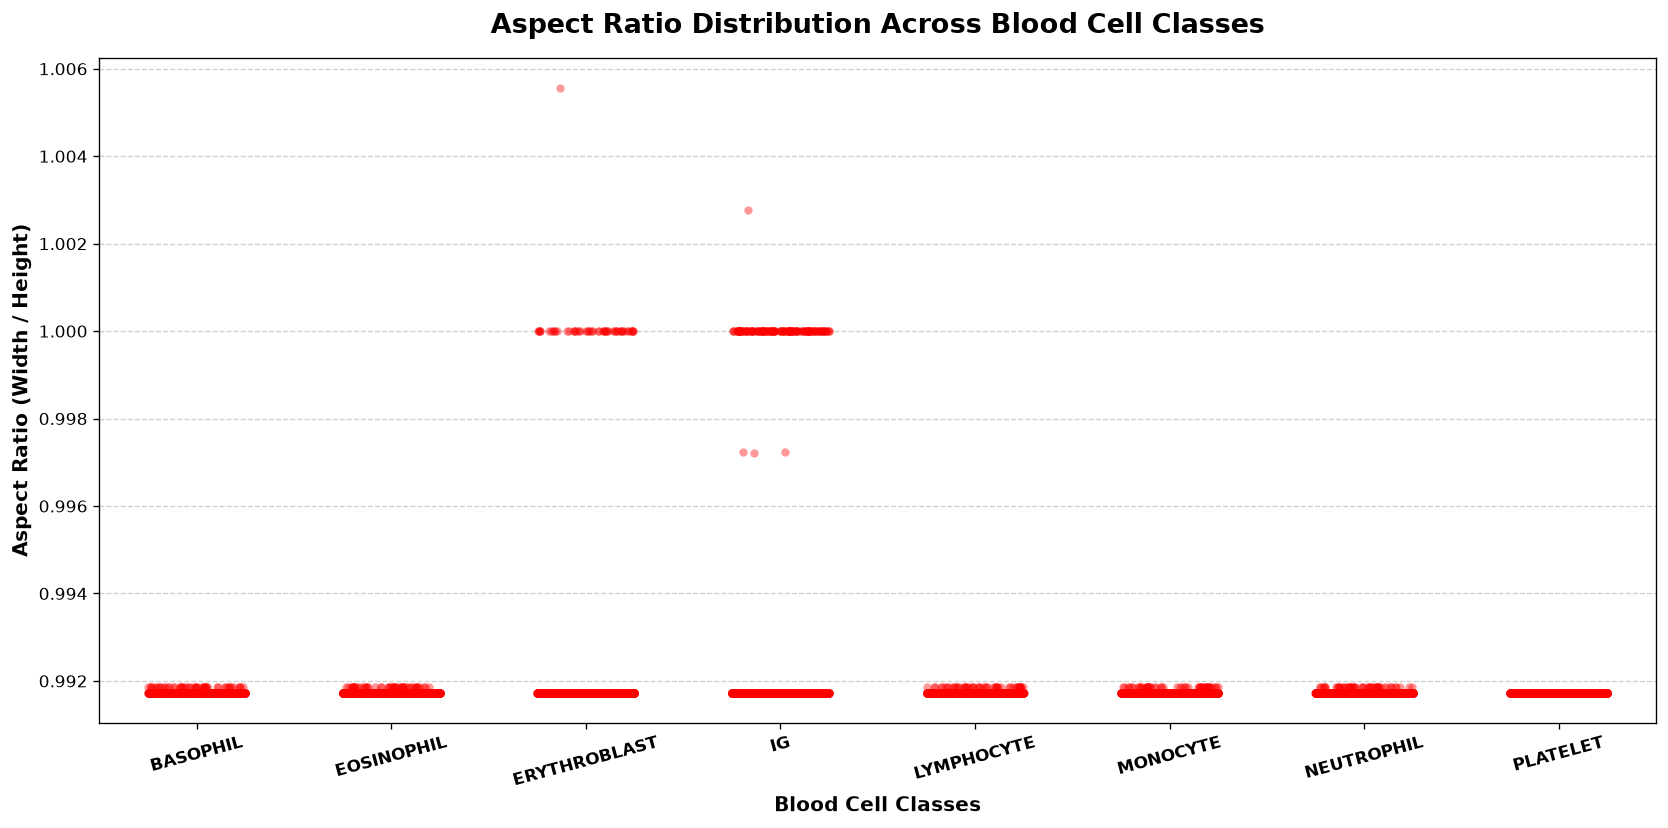

In [3]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to your processed images dataset directory
original_dir = r"E:\Liora\Project\Dataset\blood_cells\PBC_dataset_normal_DIB"
classes = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

aspect_ratio_data = []

print("=== Extracting Aspect Ratios across 8 Blood Cell Classes ===")

# 1. Iterate through class directories and compute aspect ratios
for cls in classes:
    class_folder = os.path.join(original_dir, cls)
    if not os.path.exists(class_folder):
        continue
        
    files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    for f in files:
        img_path = os.path.join(class_folder, f)
        img = cv2.imread(img_path)
        
        if img is not None:
            height, width, _ = img.shape
            aspect_ratio = width / float(height)
            
            aspect_ratio_data.append({
                'Class': cls.upper(),
                'Aspect_Ratio': aspect_ratio
            })

# 2. Convert to Pandas DataFrame
df_aspect = pd.DataFrame(aspect_ratio_data)

# 3. Plotting the Aspect Ratio Distribution
plt.figure(figsize=(14, 7), dpi=120)

# Stripplot creates the scatter plot distribution with red dots
sns.stripplot(
    data=df_aspect, 
    x='Class', 
    y='Aspect_Ratio', 
    color='red',         # Red dots as requested
    alpha=0.4,           # Slight transparency for overlapping points
    jitter=0.25,         # Spread dots horizontally for clear distribution view
    size=5
)

# Customize plot title and axes
plt.title('Aspect Ratio Distribution Across Blood Cell Classes', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Blood Cell Classes', fontsize=12, fontweight='bold')
plt.ylabel('Aspect Ratio (Width / Height)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

=== Extracting Original Image Sizes Across 8 Classes ===


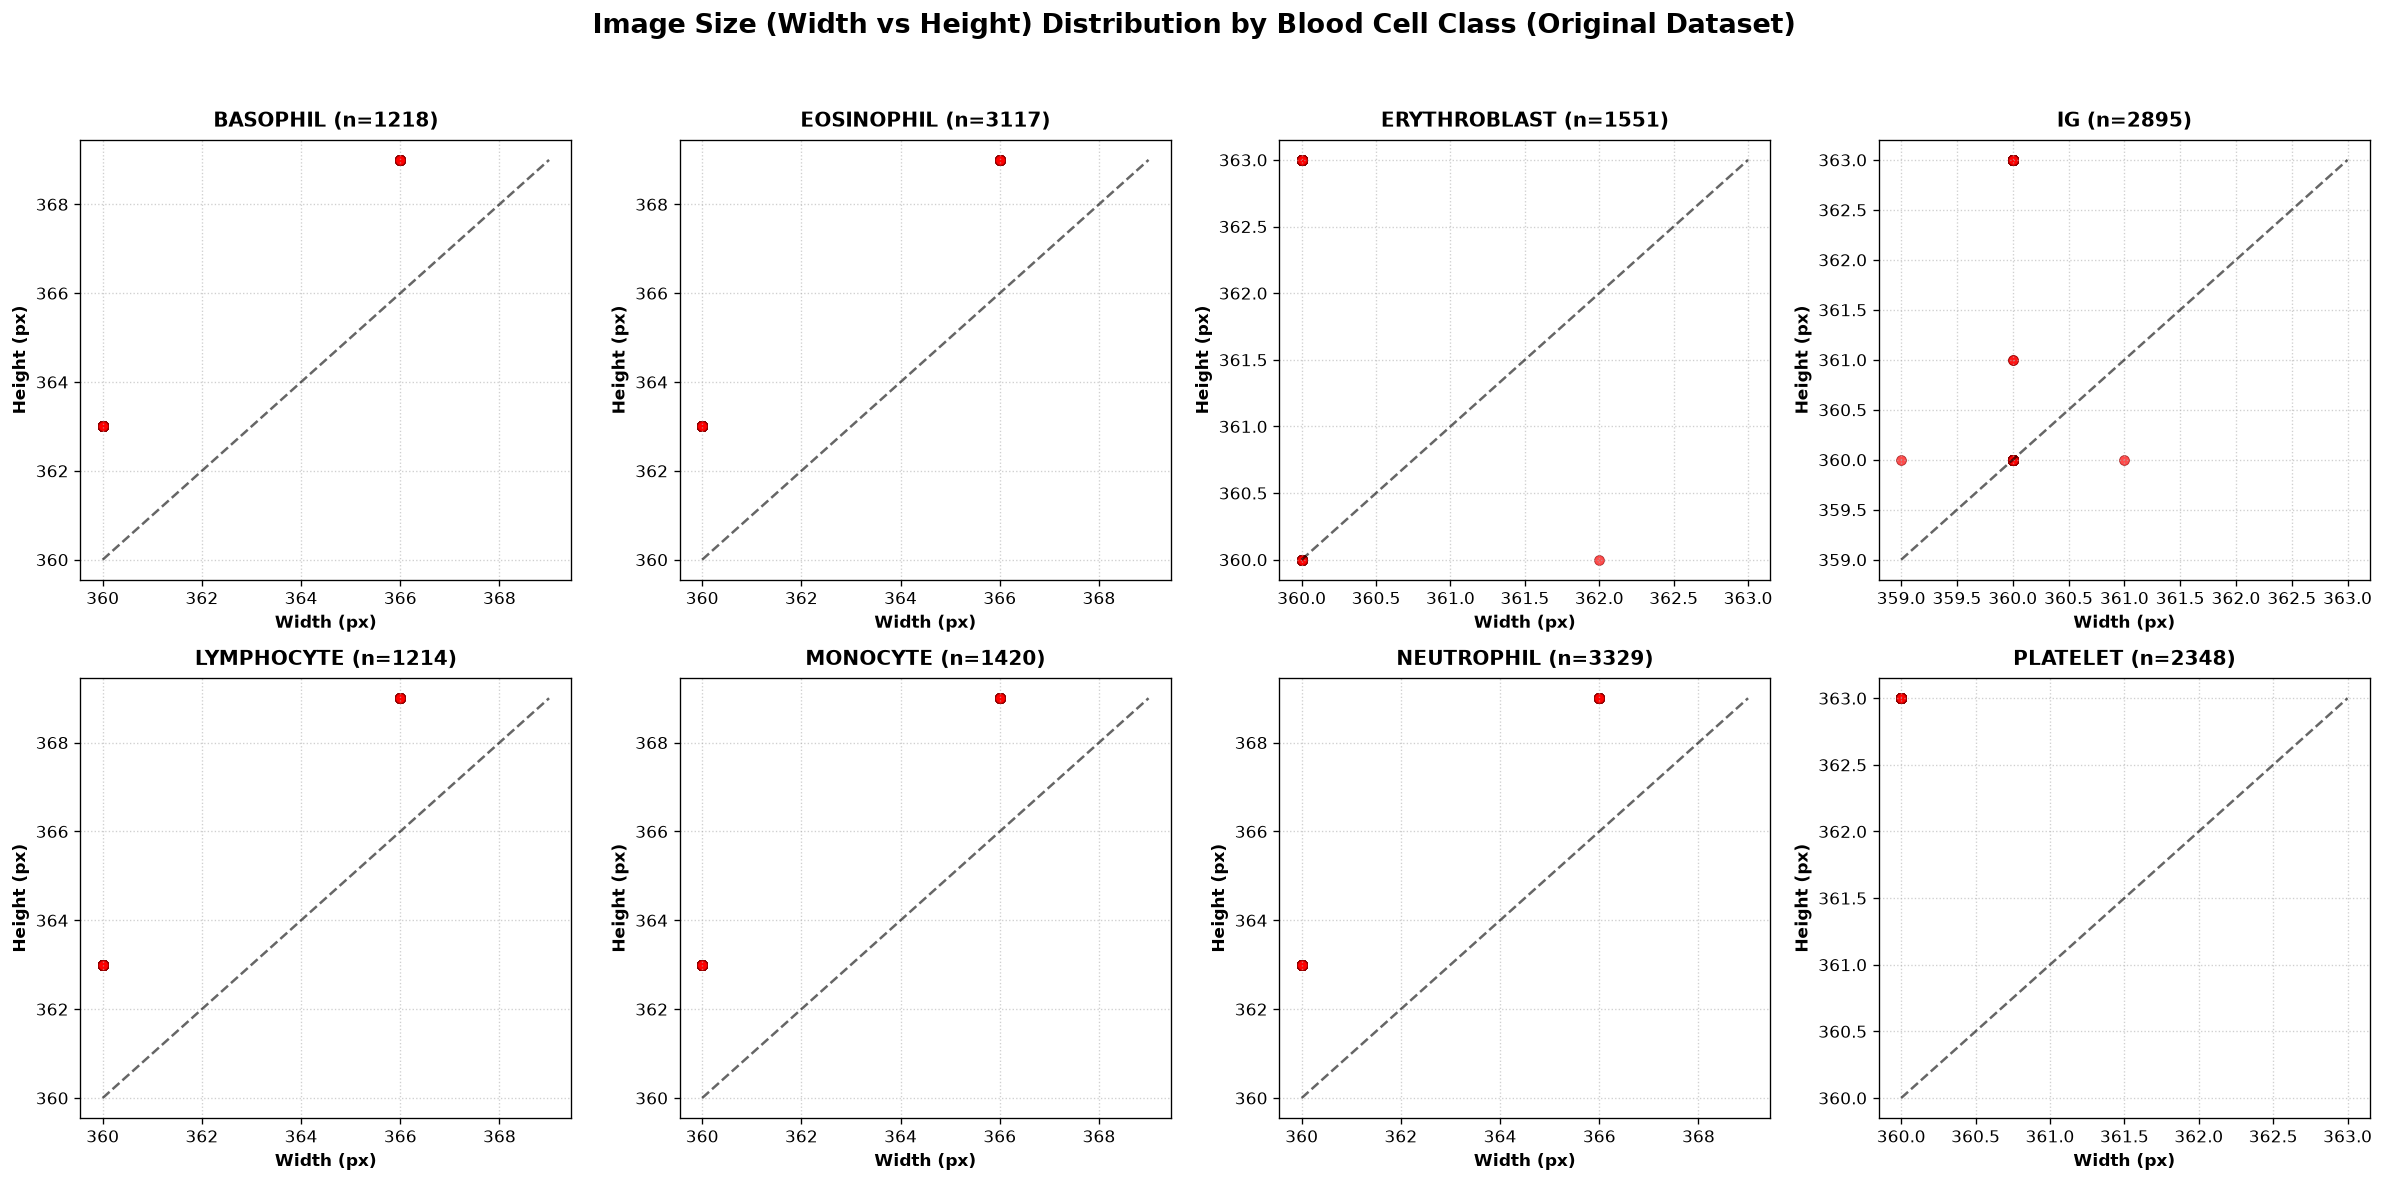

In [7]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your ORIGINAL images dataset directory
original_dir = r"E:\Liora\Project\Dataset\blood_cells\PBC_dataset_normal_DIB"
classes = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

# Dictionary to hold dimensions per class
class_data = {cls: {'width': [], 'height': []} for cls in classes}

print("=== Extracting Original Image Sizes Across 8 Classes ===")

# 1. Read sizes from the original image directory
for cls in classes:
    class_folder = os.path.join(original_dir, cls)
    if not os.path.exists(class_folder):
        print(f"Warning: Directory not found: {class_folder}")
        continue
        
    files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    for f in files:
        img_path = os.path.join(class_folder, f)
        img = cv2.imread(img_path)
        
        if img is not None:
            h, w, _ = img.shape
            class_data[cls]['width'].append(w)
            class_data[cls]['height'].append(h)

# 2. Setup a 2x4 Subplot Grid (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), dpi=120)
axes = axes.flatten()  # Flatten into 1D array for easy iteration

# 3. Plot individual scatter graphs with bold red dots for each class
for idx, cls in enumerate(classes):
    ax = axes[idx]
    widths = class_data[cls]['width']
    heights = class_data[cls]['height']
    
    if len(widths) > 0:
        # Scatter plot using bold red color across all subplots
        ax.scatter(
            widths, 
            heights, 
            color='red',          # Unified red color for all classes
            alpha=0.7,          # Increased opacity for better visibility
            s=35,               # Larger dot size to make points bold
            edgecolors='darkred',# Dark red outline to make points pop
            linewidth=0.5
        )
        
        # Reference diagonal line (square aspect ratio w = h)
        min_dim = min(min(widths), min(heights))
        max_dim = max(max(widths), max(heights))
        ax.plot([min_dim, max_dim], [min_dim, max_dim], color='black', linestyle='--', alpha=0.6, label='1:1 Ratio')
        
    ax.set_title(f"{cls.upper()} (n={len(widths)})", fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Width (px)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Height (px)', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Image Size (Width vs Height) Distribution by Blood Cell Class (Original Dataset)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

=== Loading All Four Saved Models for Synchronized Evaluation ===
Evaluating test dataset in synchronized batches...
=== Plotting 2x2 Confusion Matrix Comparison ===


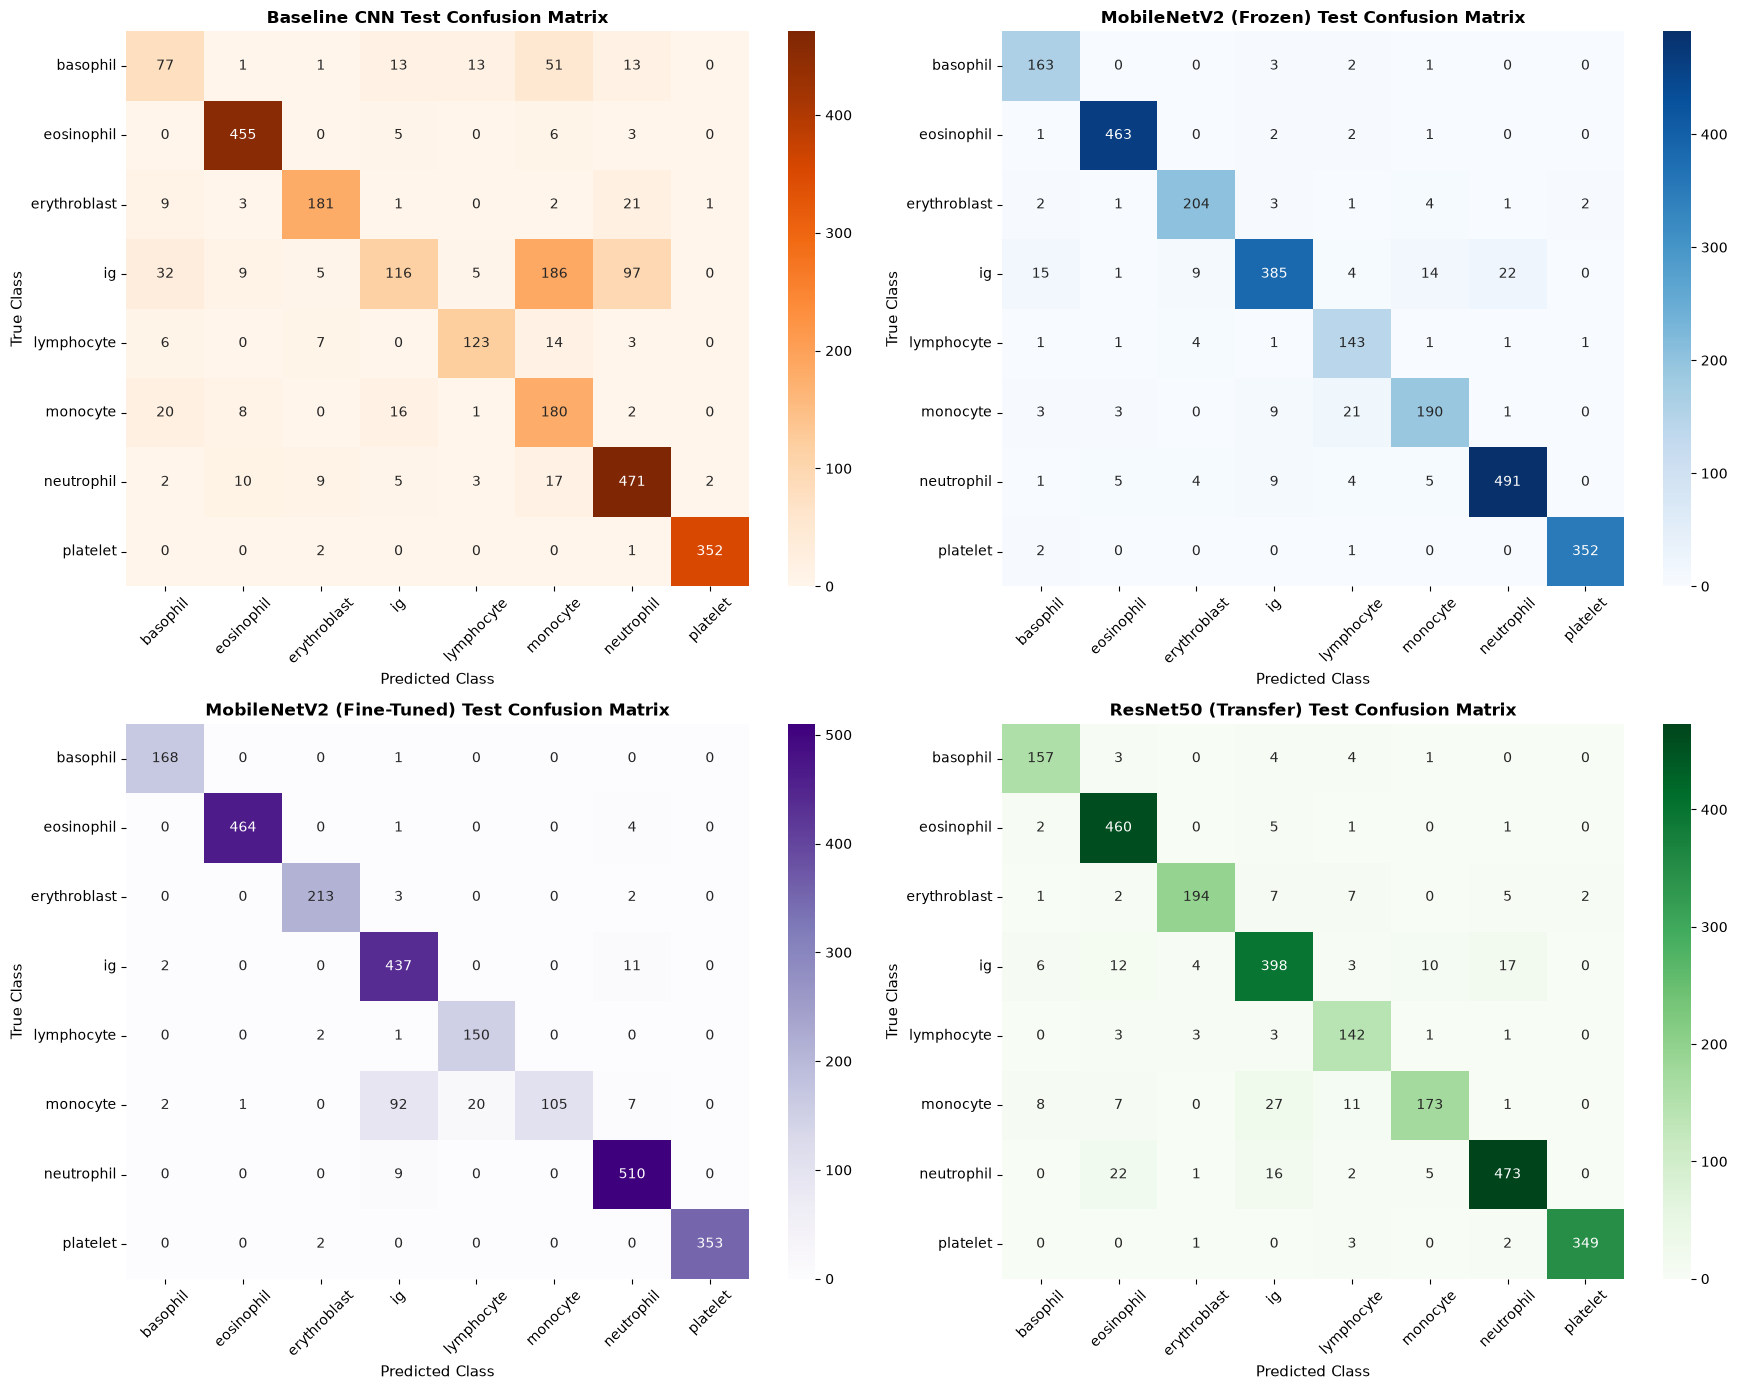

In [12]:
# New Cell — 2x2 Confusion Matrix Comparison: Baseline CNN & MobileNetV2 (Frozen)
# on top, MobileNetV2 (Fine-Tuned) & ResNet50 on bottom

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix

print("=== Loading All Four Saved Models for Synchronized Evaluation ===")

model_baseline_eval = tf.keras.models.load_model('baseline_model_best.keras')
model_mbv2_frozen   = tf.keras.models.load_model('mobilenet_model_best.keras')
model_mbv2_finetune = tf.keras.models.load_model('mobilenet_finetuned_best.keras')
model_resnet_eval   = tf.keras.models.load_model('resnet50_best.keras')

# Single synchronized pass over the test set so all four models are
# scored on the exact same batches (same approach as Cell 13)
y_true = []
preds_baseline_list = []
preds_mbv2_frozen_list = []
preds_mbv2_finetune_list = []
preds_resnet_list = []

print("Evaluating test dataset in synchronized batches...")

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

    batch_preds_baseline = model_baseline_eval.predict(images, verbose=0)
    batch_preds_mbv2_frozen = model_mbv2_frozen.predict(images, verbose=0)
    batch_preds_mbv2_finetune = model_mbv2_finetune.predict(images, verbose=0)
    batch_preds_resnet = model_resnet_eval.predict(images, verbose=0)

    preds_baseline_list.extend(np.argmax(batch_preds_baseline, axis=1))
    preds_mbv2_frozen_list.extend(np.argmax(batch_preds_mbv2_frozen, axis=1))
    preds_mbv2_finetune_list.extend(np.argmax(batch_preds_mbv2_finetune, axis=1))
    preds_resnet_list.extend(np.argmax(batch_preds_resnet, axis=1))

y_true = np.array(y_true)
preds_baseline = np.array(preds_baseline_list)
preds_mbv2_frozen = np.array(preds_mbv2_frozen_list)
preds_mbv2_finetune = np.array(preds_mbv2_finetune_list)
preds_resnet = np.array(preds_resnet_list)

# Confusion matrices
cm_baseline = confusion_matrix(y_true, preds_baseline)
cm_mbv2_frozen = confusion_matrix(y_true, preds_mbv2_frozen)
cm_mbv2_finetune = confusion_matrix(y_true, preds_mbv2_finetune)
cm_resnet = confusion_matrix(y_true, preds_resnet)

print("=== Plotting 2x2 Confusion Matrix Comparison ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top-left: Baseline CNN
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('Baseline CNN Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Class', fontsize=11)
axes[0, 0].set_ylabel('True Class', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=45)

# Top-right: MobileNetV2 (Frozen, Stage 1)
sns.heatmap(cm_mbv2_frozen, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 1])
axes[0, 1].set_title('MobileNetV2 (Frozen) Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Class', fontsize=11)
axes[0, 1].set_ylabel('True Class', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=45)

# Bottom-left: MobileNetV2 (Fine-Tuned)
sns.heatmap(cm_mbv2_finetune, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
axes[1, 0].set_title('MobileNetV2 (Fine-Tuned) Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted Class', fontsize=11)
axes[1, 0].set_ylabel('True Class', fontsize=11)
axes[1, 0].tick_params(axis='x', rotation=45)

# Bottom-right: ResNet50 (Frozen Transfer)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 1])
axes[1, 1].set_title('ResNet50 (Transfer) Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted Class', fontsize=11)
axes[1, 1].set_ylabel('True Class', fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()